In [ ]:
pip install matplotlib
pip install wordcloud

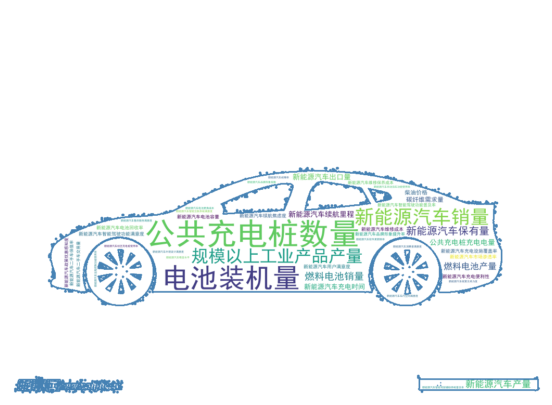

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 数据
data = {
    "公共充电桩数量": 0.647,
    "电池装机量": 0.532,
    "规模以上工业产品产量": 0.319,
    "新能源汽车产量": 0.215,
    "公共充电桩充电电量": 0.183,
    "燃料电池销量": 0.235,
    "燃料电池产量": 0.191,
    "新能源汽车销量": 0.331,
    "碳纤维需求量": 0.131,
    "柴油价格": 0.111,
    "新能源汽车保有量": 0.250,
    "新能源汽车出口量": 0.180,
    "新能源汽车续航里程": 0.175,
    "新能源汽车充电时间": 0.160,
    "新能源汽车电池容量": 0.070,
    "新能源汽车市场渗透率": 0.078,
    "新能源汽车充电设施覆盖率": 0.065,
    "新能源汽车电池回收率": 0.059,
    "新能源汽车智能驾驶功能普及率": 0.052,
    "新能源汽车维修保养成本": 0.048,
    "新能源汽车二手车交易量": 0.042,
    "新能源汽车政策支持力度": 0.037,
    "新能源汽车消费者满意度": 0.034,
    "新能源汽车品牌形象指数": 0.029,
    "新能源汽车用户满意度": 0.075,
    "新能源汽车维修成本": 0.068,
    "新能源汽车智能驾驶功能满意度": 0.062,
    "新能源汽车续航焦虑度": 0.057,
    "新能源汽车充电便利性": 0.053,
    "新能源汽车品牌形象提升率": 0.049,
    "新能源汽车二手车保值率": 0.045,
    "新能源汽车政策优惠感知度": 0.041,
    "新能源汽车社区充电桩使用率": 0.038,
    "新能源汽车电池更换成本": 0.035,
    "新能源汽车智能互联系统满意度": 0.033,
    "新能源汽车外观设计满意度": 0.030,
    "新能源汽车车内空间满意度": 0.028,
    "新能源汽车噪音水平": 0.026,
    "新能源汽车售后服务满意度": 0.024,
    "新能源汽车故障率": 0.022,
    "新能源汽车软件更新频率": 0.020,
    "新能源汽车智能驾驶辅助系统普及率": 0.018,
    "新能源汽车自动泊车功能使用率": 0.016,
    "新能源汽车远程控制功能使用率": 0.014
}

# 加载小汽车形状的蒙版图像
mask = np.array(Image.open('car_mask.png'))  # 确保此文件在代码运行目录中

# 生成词云图
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    font_path='simhei.ttf',  # 使用黑体字体，确保中文显示正确
    mask=mask,  # 设置词云形状为小汽车形状
    contour_width=3,  # 添加轮廓线宽度
    contour_color='steelblue'  # 设置轮廓线颜色
).generate_from_frequencies(data)

# 显示词云图
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
!pip install pandas statsmodels openpyxl matplotlib scipy
# 配置参数
FILE_PATH = "已处理数据.xls"
TARGET_COLUMN = "新能源汽车销量 (辆)"
OUTPUT_FILE = "预处理后数据.xlsx"

def load_data(file_path):
    """加载特殊格式的Excel文件"""
    # 读取前三行元数据
    meta = pd.read_excel(file_path, header=None, nrows=3)
    
    # 构建列名
    units = meta.iloc[1].apply(lambda x: x.split("：")[-1] if "单位" in str(x) else "")
    headers = meta.iloc[2].astype(str) + " (" + units.astype(str) + ")"
    headers = [h.replace(" ()", "") for h in headers]
    
    # 加载实际数据
    df = pd.read_excel(file_path, skiprows=3, header=None)
    df.columns = headers
    
    # 处理日期列
    date_col = headers[0]
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col).apply(pd.to_numeric, errors='coerce').dropna()

def residual_analysis(df, target_col):
    """执行残差分析预处理"""
    # 准备数据
    y = df[target_col]
    X = sm.add_constant(df.drop(columns=[target_col]))
    
    # 拟合模型
    model = sm.OLS(y, X).fit()
    
    # 计算学生化残差
    student_resid = model.get_influence().resid_studentized
    
    # 检测异常值（99%置信区间）
    p_values = 2 * (1 - stats.t.cdf(np.abs(student_resid), df=len(y)-X.shape[1]))
    outliers = p_values < 0.01
    
    # 生成诊断图
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # 残差散点图
    axs[0].scatter(model.fittedvalues, student_resid, alpha=0.6)
    axs[0].axhline(0, color='r', linestyle='--')
    axs[0].set_title('Residuals vs Fitted')
    axs[0].set_xlabel('Fitted values')
    axs[0].set_ylabel('Studentized residuals')
    
    # 正态概率图
    stats.probplot(student_resid, dist="norm", plot=axs[1])
    axs[1].set_title('Normal Q-Q Plot')
    
    # 残差分布
    axs[2].hist(student_resid, bins=15, density=True, alpha=0.6)
    x = np.linspace(-4, 4, 100)
    axs[2].plot(x, stats.norm.pdf(x), 'r-')
    axs[2].set_title('Residual Distribution')
    
    plt.tight_layout()
    plt.show()
    
    return df[~outliers], model

# 主程序
if __name__ == "__main__":
    try:
        # 加载数据
        df = load_data(FILE_PATH)
        print(f"成功加载数据，维度：{df.shape}")
        
        # 执行残差分析
        cleaned_df, model = residual_analysis(df, TARGET_COLUMN)
        print(f"异常值剔除数量：{len(df) - len(cleaned_df)}")
        
        # 保存结果
        cleaned_df.to_excel(OUTPUT_FILE)
        print(f"预处理完成，结果已保存至：{OUTPUT_FILE}")
        
        # 显示模型摘要
        print("\n回归模型摘要：")
        print(model.summary())
        
    except Exception as e:
        print(f"处理失败：{str(e)}")

成功加载数据，维度：(72, 7)
处理失败：'新能源汽车销量 (辆)'


In [9]:
# 数据预处理
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
from scipy import stats

# 读取数据
raw_data = pd.read_excel('已处理数据.xls', header=None)

# 提取单位和列名
units = raw_data.iloc[1, 1:].tolist()          # 第二行是单位
col_names = raw_data.iloc[2, 1:].tolist()      # 第三行是列名
dates = raw_data.iloc[3:, 0].values            # 第一列是日期

# 构建数据框
df = pd.DataFrame(raw_data.iloc[3:, 1:].values, 
                 columns=col_names,
                 index=pd.to_datetime(dates))
df = df.apply(pd.to_numeric, errors='coerce')

# 1. 线性回归残差检测异常值
outliers_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.columns:
    try:
        # 生成时间序列特征
        X = np.arange(len(df)).reshape(-1, 1)
        y = df[col].values.reshape(-1, 1)
        
        # 训练回归模型
        reg = LinearRegression().fit(X[~np.isnan(y)], y[~np.isnan(y)])
        y_pred = reg.predict(X)
        residuals = y.flatten() - y_pred.flatten()
        
        # 检测异常值（3σ原则）
        z_scores = np.abs(stats.zscore(residuals[~np.isnan(residuals)]))
        outliers = np.abs(residuals) > 3 * np.nanstd(residuals)
        outliers_mask[col] = outliers
    except:
        continue

# 标记异常值为NaN
df[outliers_mask] = np.nan

# 2. 趋势分解填充
for col in df.columns:
    try:
        # STL分解
        stl = STL(df[col], period=12, robust=True)
        res = stl.fit()
        
        # 使用趋势+周期分量填充
        df[col] = df[col].fillna(res.trend + res.seasonal)
    except:
        # 简单线性插值作为备选方案
        df[col] = df[col].interpolate(method='linear')

# 3. 滑动四分位检验
window_size = 12  # 年度周期
iqr_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.columns:
    rolling = df[col].rolling(window=window_size, min_periods=1)
    q1 = rolling.quantile(0.25)
    q3 = rolling.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    iqr_mask[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

# 输出最终数据
output_df = pd.DataFrame(
    [[''] + units,  # 单位行
     ['结束日期'] + col_names] +  # 列名行
    [[df.index[i].strftime('%Y-%m-%d')] + row for i, row in enumerate(df.values.tolist())]
)

output_df.to_excel('processed_data.xlsx', index=False, header=False)

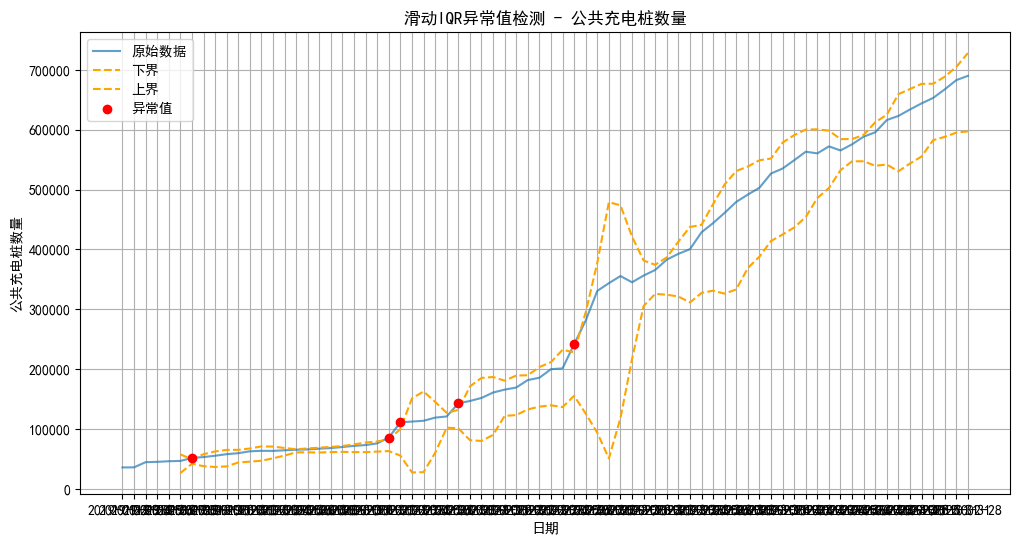

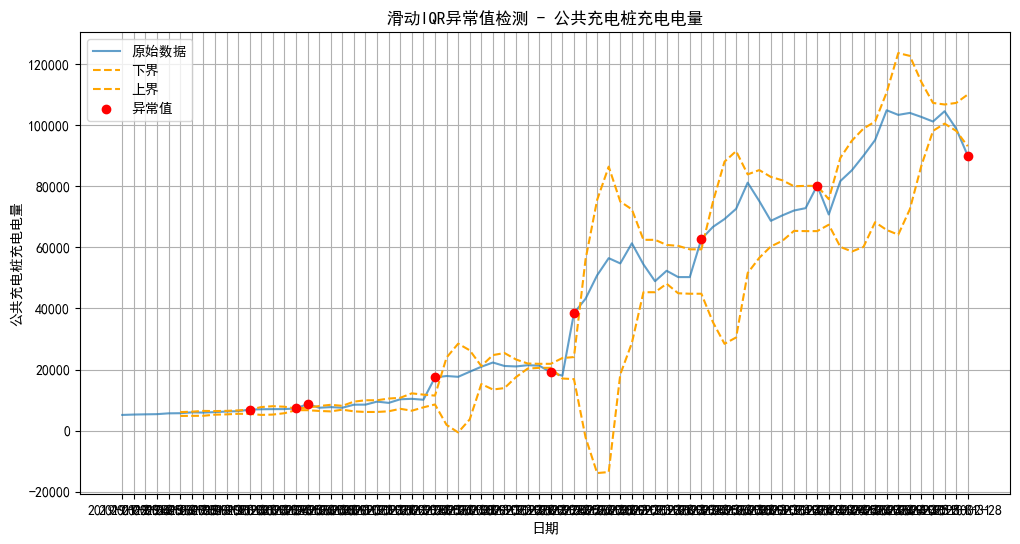

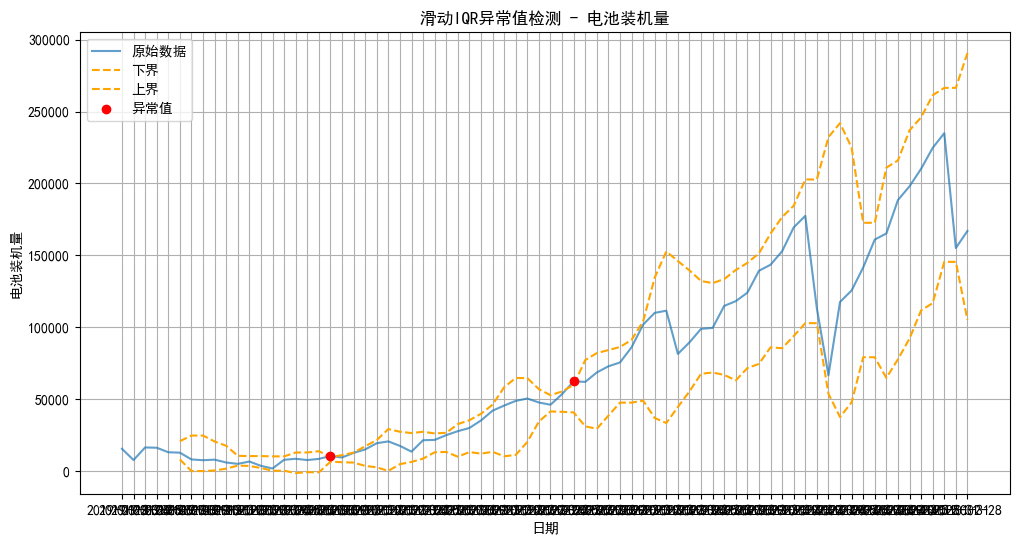

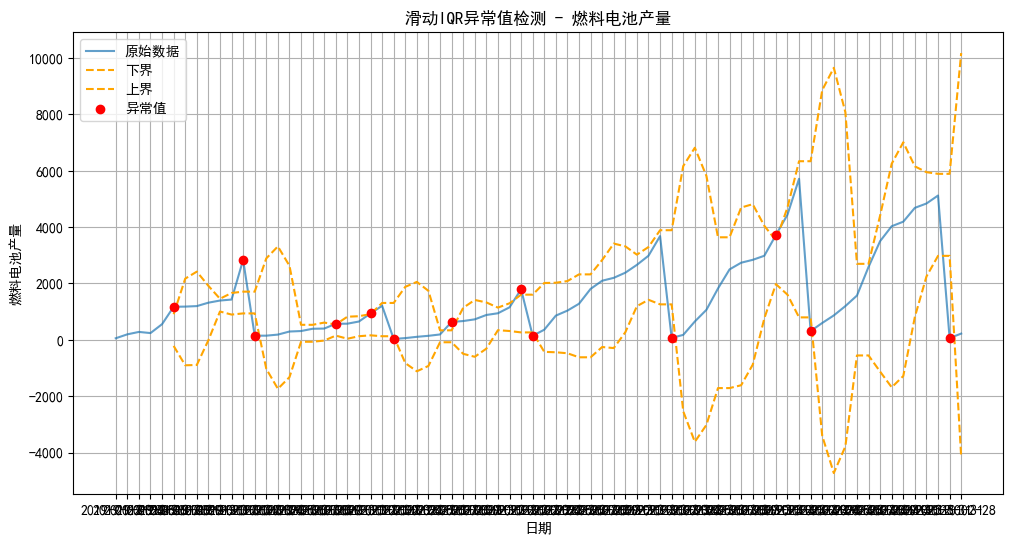

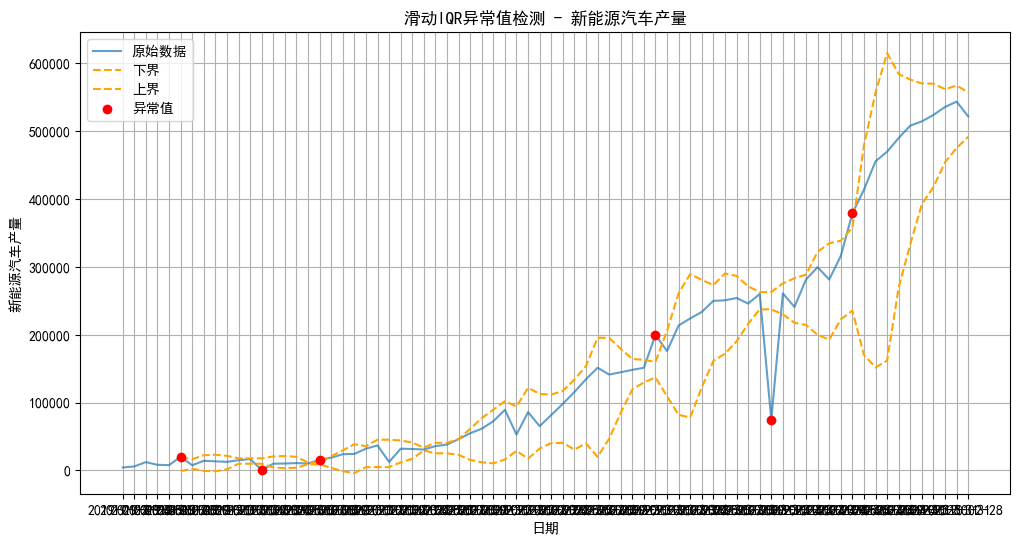

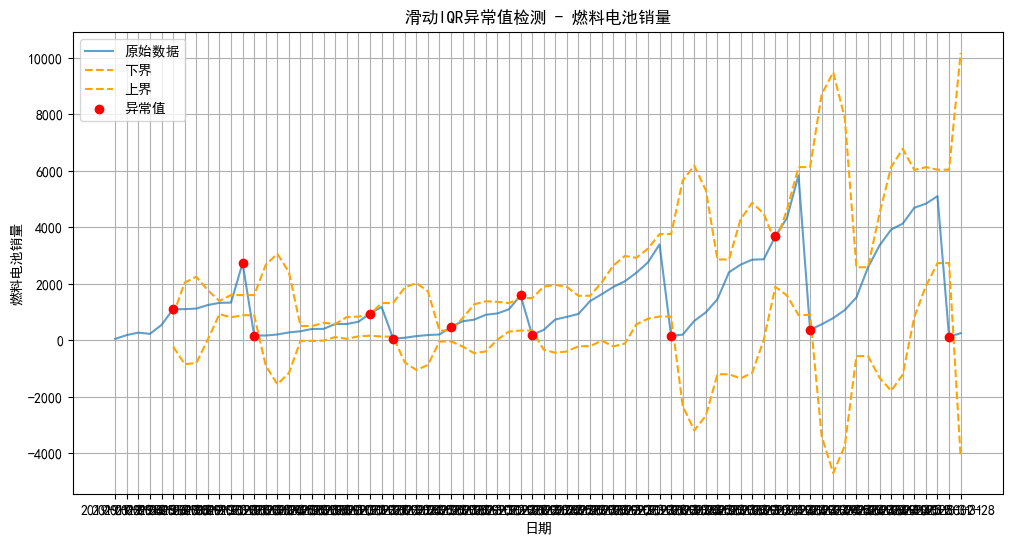

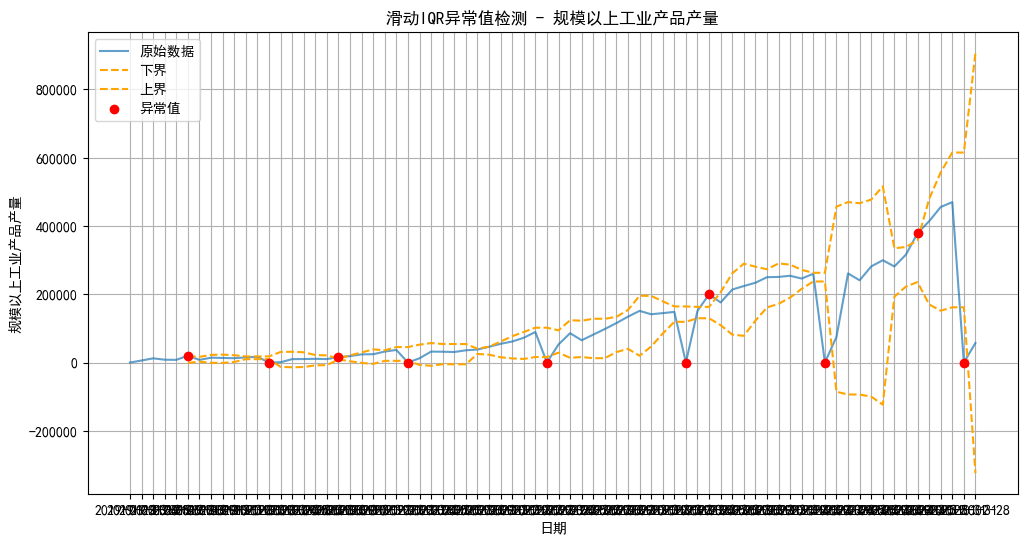

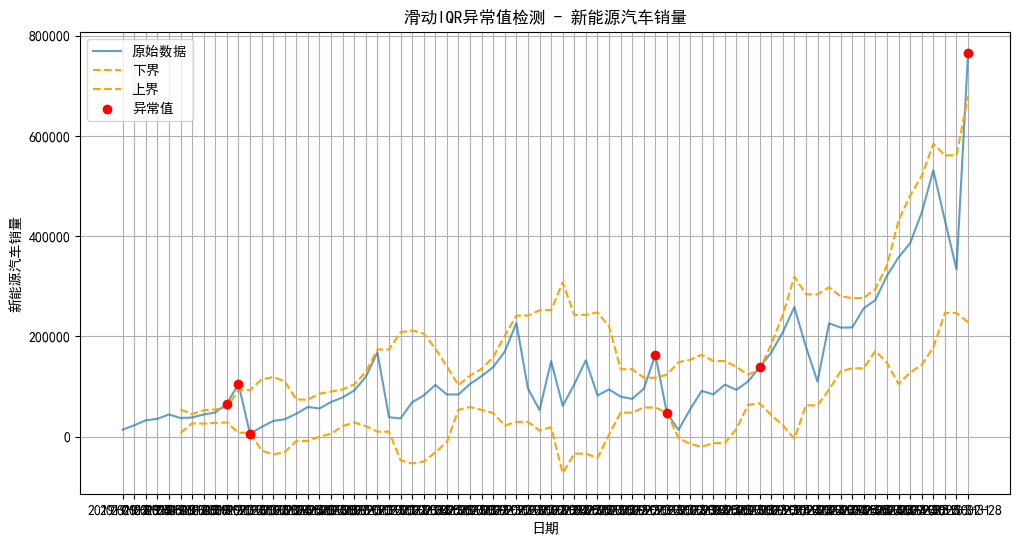

所有变量中共有 64 个异常值


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号('-')显示为方块的问题

df = pd.read_excel('数据描述量.xlsx', header=0)  

# 设置日期列为索引
df.set_index('结束日期', inplace=True)


# 滑动四分位间距法检验异常值
def rolling_iqr(df, column_name, window_size=6):
    """
    使用滑动四分位间距法检验异常值
    :param df: 输入的DataFrame
    :param column_name: 需要检验的列名
    :param window_size: 滑动窗口大小，默认为6
    :return: 包含异常值信息的DataFrame
    """
    # 计算滑动窗口的四分位数
    rolling_q1 = df[column_name].rolling(window=window_size).quantile(0.25)
    rolling_q3 = df[column_name].rolling(window=window_size).quantile(0.75)
    rolling_iqr = rolling_q3 - rolling_q1

    # 计算异常值的上下界
    lower_bound = rolling_q1 - 1.5 * rolling_iqr
    upper_bound = rolling_q3 + 1.5 * rolling_iqr

    # 标记异常值
    outliers = (df[column_name] < lower_bound) | (df[column_name] > upper_bound)

    # 创建结果DataFrame
    result = pd.DataFrame({
        'value': df[column_name],
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'is_outlier': outliers
    })

    return result

# 初始化总异常值计数
total_outliers = 0

# 遍历所有列，应用滑动四分位间距法
for column in df.columns:
    result = rolling_iqr(df, column)
    # 计算异常值的数量
    outlier_count = result['is_outlier'].sum()
    total_outliers += outlier_count
    # 异常值可视化
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column], label='原始数据', alpha=0.7)
    plt.plot(df.index, result['lower_bound'], label='下界', linestyle='--', color='orange')
    plt.plot(df.index, result['upper_bound'], label='上界', linestyle='--', color='orange')
    plt.scatter(df.index[result['is_outlier']], df[column][result['is_outlier']], 
                color='red', label='异常值', zorder=5)
    plt.title(f'滑动IQR异常值检测 - {column}')
    plt.xlabel('日期')
    plt.ylabel(column)
    plt.legend()
    plt.grid(True)
    plt.show()

# 输出总异常值数量
print(f'所有变量中共有 {total_outliers} 个异常值')

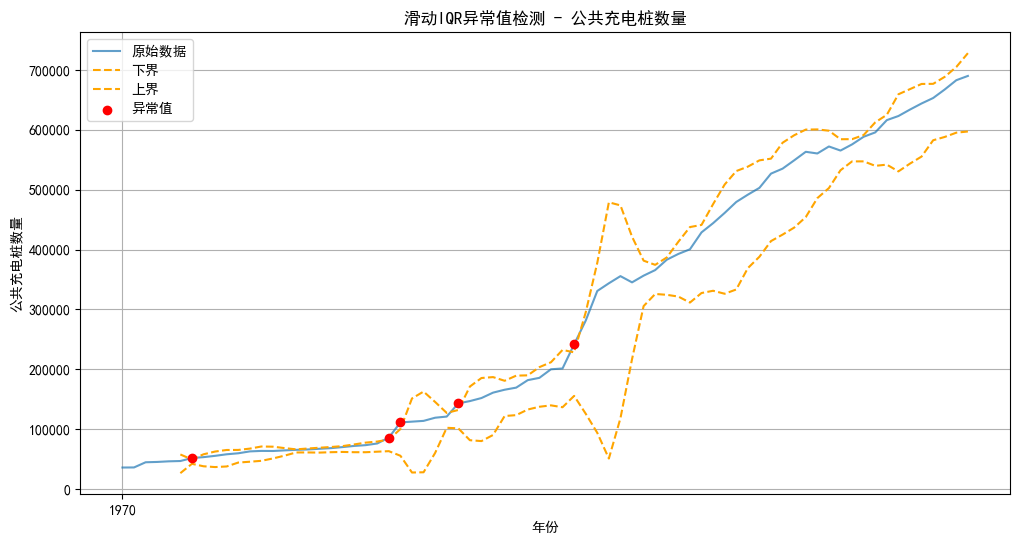

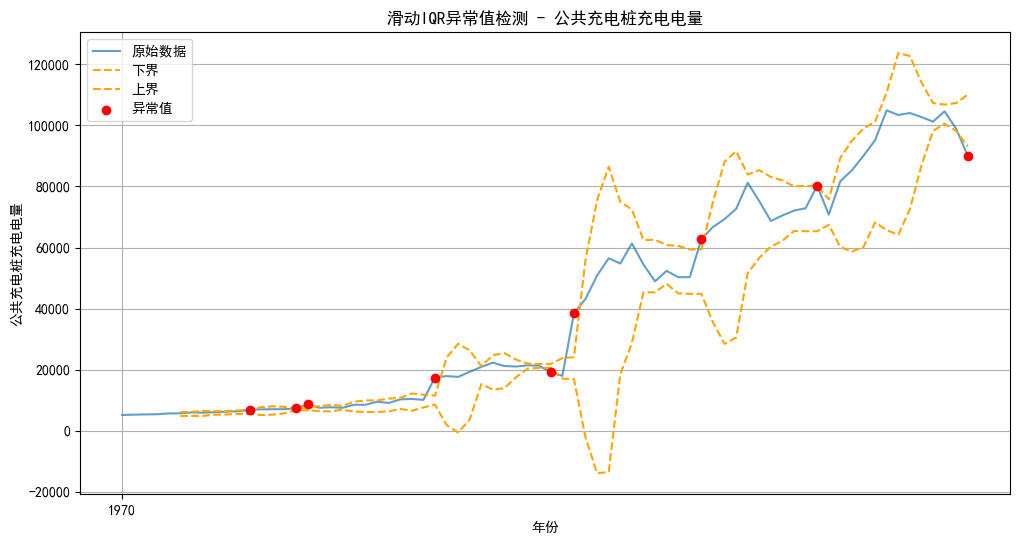

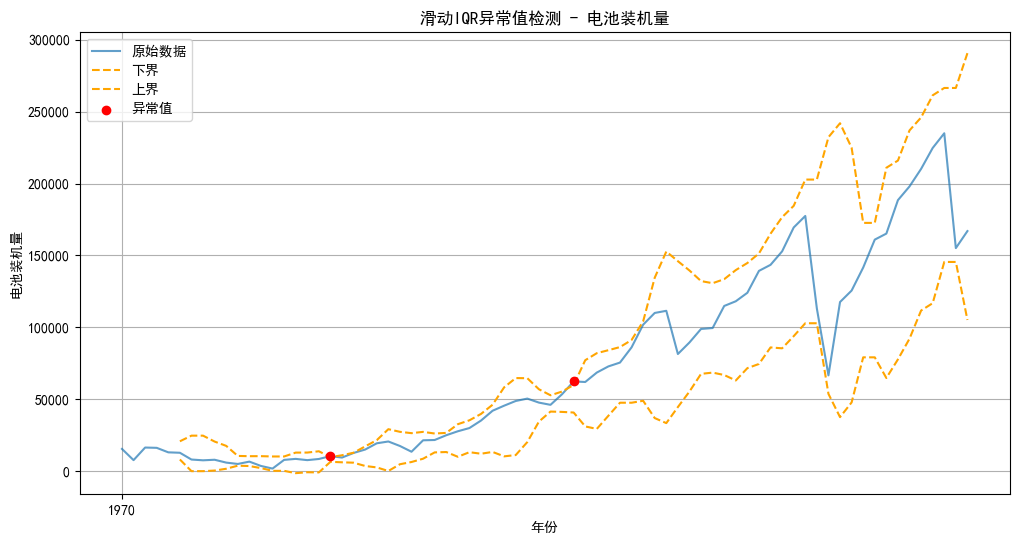

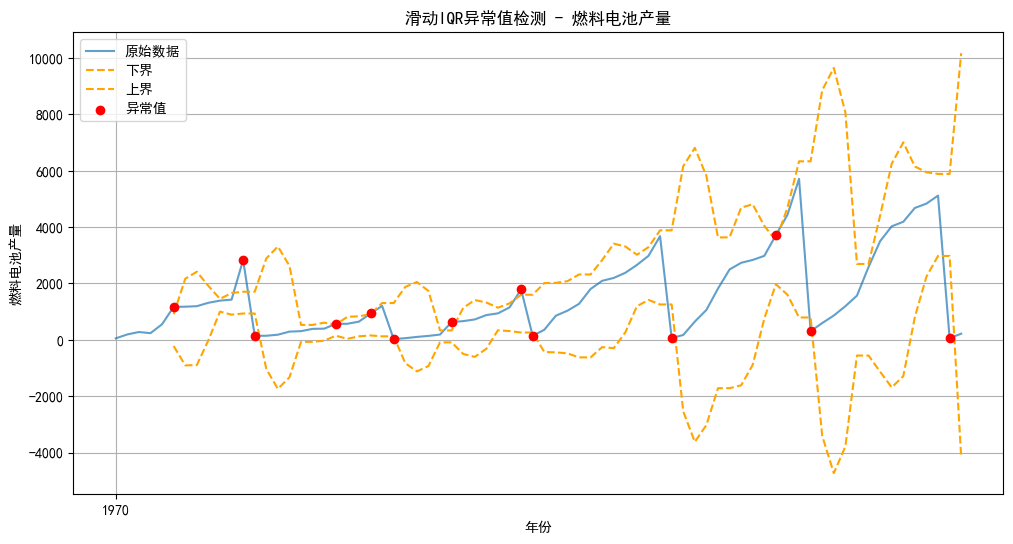

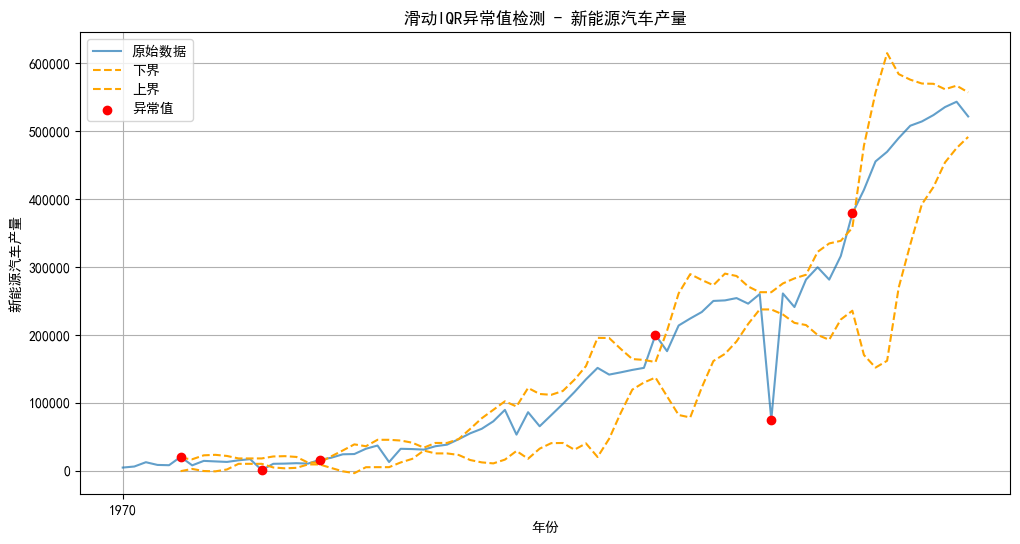

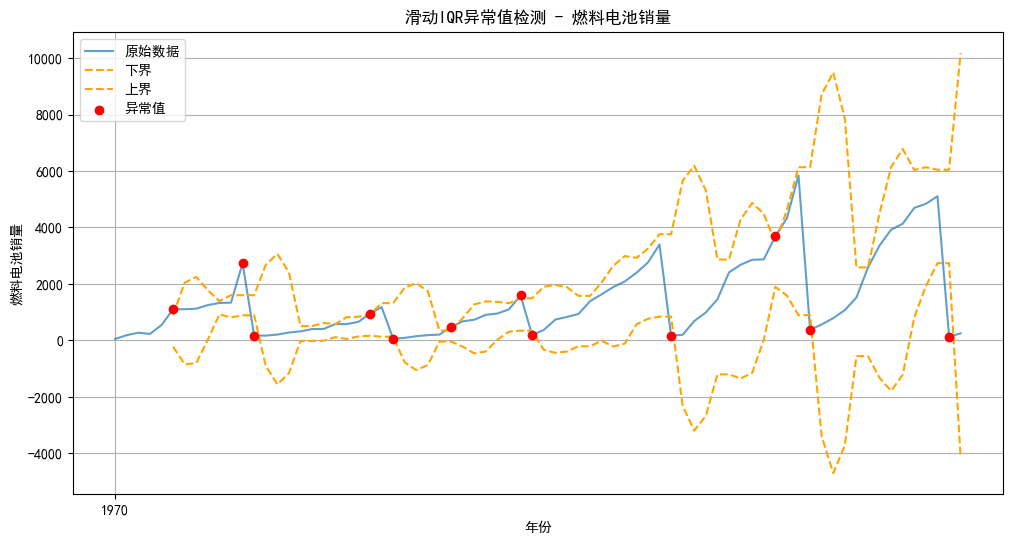

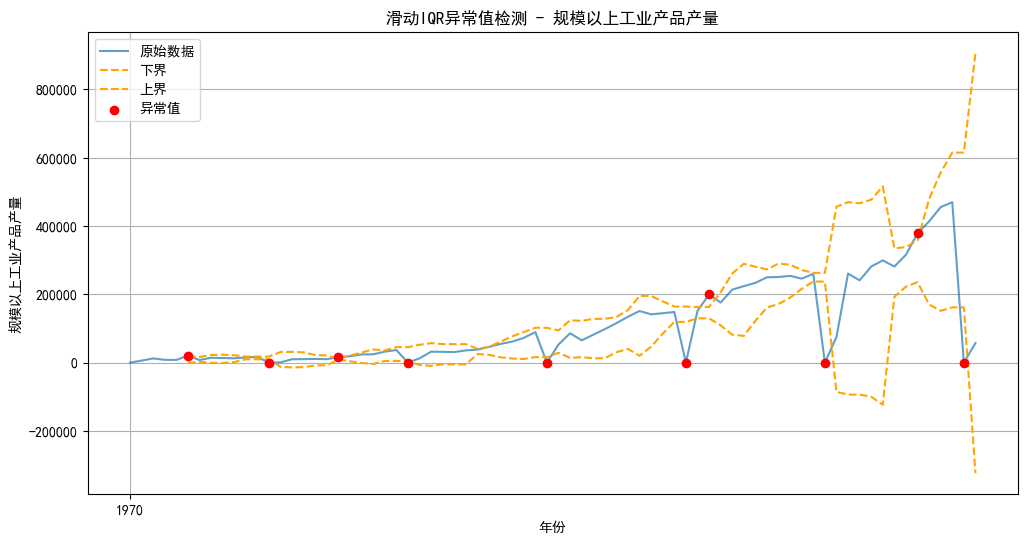

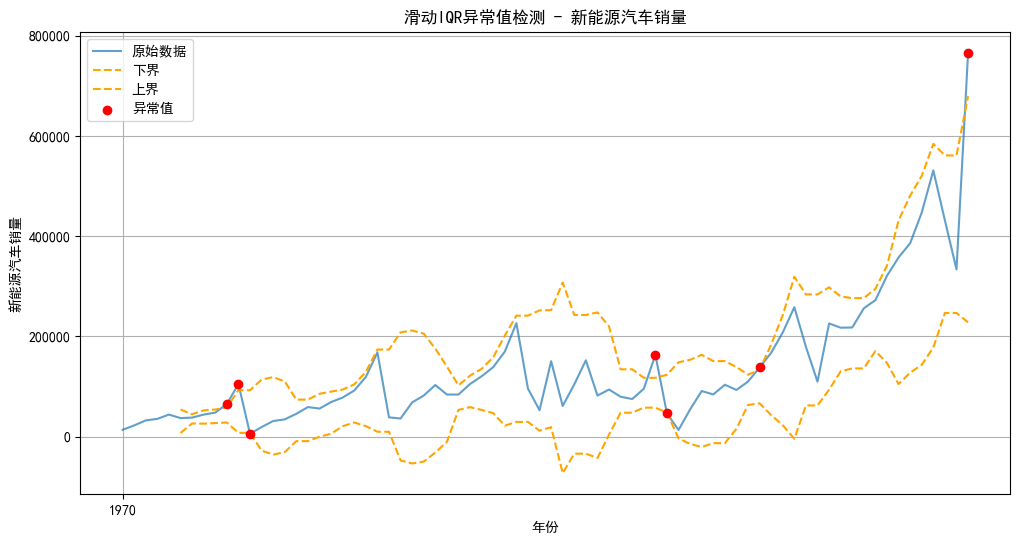

所有变量中共有 64 个异常值


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
df = pd.read_excel('数据描述量.xlsx', header=0)  # 请确保文件路径正确

# 设置日期列为索引
df.set_index('结束日期', inplace=True)


# 滑动四分位间距法检验异常值
def rolling_iqr(df, column_name, window_size=6):
    """
    使用滑动四分位间距法检验异常值
    :param df: 输入的DataFrame
    :param column_name: 需要检验的列名
    :param window_size: 滑动窗口大小，默认为6
    :return: 包含异常值信息的DataFrame
    """
    # 计算滑动窗口的四分位数
    rolling_q1 = df[column_name].rolling(window=window_size).quantile(0.25)
    rolling_q3 = df[column_name].rolling(window=window_size).quantile(0.75)
    rolling_iqr = rolling_q3 - rolling_q1

    # 计算异常值的上下界
    lower_bound = rolling_q1 - 1.5 * rolling_iqr
    upper_bound = rolling_q3 + 1.5 * rolling_iqr

    # 标记异常值
    outliers = (df[column_name] < lower_bound) | (df[column_name] > upper_bound)

    # 创建结果DataFrame
    result = pd.DataFrame({
        'value': df[column_name],
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'is_outlier': outliers
    })

    return result

# 初始化总异常值计数
total_outliers = 0

# 遍历所有列，应用滑动四分位间距法
for column in df.columns:
    result = rolling_iqr(df, column)
    # 计算异常值的数量
    outlier_count = result['is_outlier'].sum()
    total_outliers += outlier_count
    
    # 异常值可视化
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column], label='原始数据', alpha=0.7)
    plt.plot(df.index, result['lower_bound'], label='下界', linestyle='--', color='orange')
    plt.plot(df.index, result['upper_bound'], label='上界', linestyle='--', color='orange')
    plt.scatter(df.index[result['is_outlier']], df[column][result['is_outlier']], 
                color='red', label='异常值', zorder=5)
    
    # 设置x轴刻度为年
    ax = plt.gca()
    ax.xaxis.set_major_locator(YearLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    
    plt.title(f'滑动IQR异常值检测 - {column}')
    plt.xlabel('年份')
    plt.ylabel(column)
    plt.legend()
    plt.grid(True)
    plt.show()

# 输出总异常值数量
print(f'所有变量中共有 {total_outliers} 个异常值')

一致性比例 CR = 0.047 通过

指标权重：
                 权重
公共充电桩数量    0.421502
公共充电桩充电电量  0.227059
电池装机量      0.118103
新能源汽车产量    0.104667
新能源汽车销量    0.050423
燃料电池产量     0.046072
燃料电池销量     0.032174


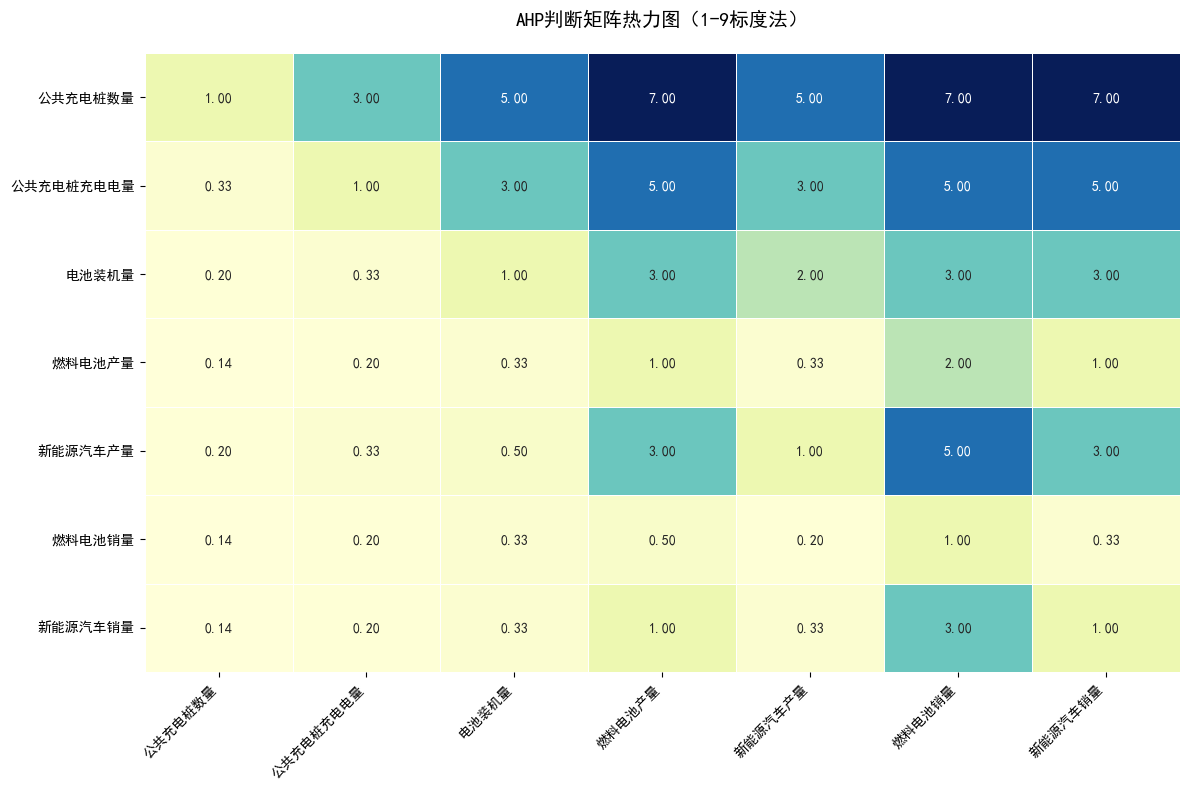

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig
# 在导入plt前设置
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示异常
#  定义指标和判断矩阵
# 基于文献《新能源汽车发展评价指标体系研究》的结论
indicators = [
    "公共充电桩数量",
    "公共充电桩充电电量",
    "电池装机量",
    "燃料电池产量",
    "新能源汽车产量",
    "燃料电池销量",
    "新能源汽车销量"
]

# 构造判断矩阵（1-9标度法）
judge_matrix = np.array([
    [1,    3,    5,    7,    5,    7,    7],   # 充电桩数量
    [1/3,  1,    3,    5,    3,    5,    5],   # 充电电量
    [1/5,  1/3,  1,    3,    2,    3,    3],   # 电池装机量
    [1/7,  1/5,  1/3,  1,    1/3,  2,    1],   # 燃料电池产量
    [1/5,  1/3,  1/2,  3,    1,    5,    3],   # 新能源汽车产量
    [1/7,  1/5,  1/3,  1/2,  1/5,  1,    1/3], # 燃料电池销量
    [1/7,  1/5,  1/3,  1,    1/3,  3,    1]    # 新能源汽车销量
])

#  一致性检验
def check_consistency(matrix):
    """检查判断矩阵的一致性"""
    n = matrix.shape[0]
    eigenvalues, _ = eig(matrix)
    max_eigen = np.max(eigenvalues.real)
    CI = (max_eigen - n) / (n - 1)
    RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41][n]  # 标准RI值
    CR = CI / RI
    return CR.real

CR = check_consistency(judge_matrix)
print(f"一致性比例 CR = {CR:.3f} {'通过' if CR < 0.1 else '不通过'}")

# 计算权重 
def calculate_weights(matrix):
    """特征向量法计算权重"""
    eigenvalues, eigenvectors = eig(matrix)
    max_eigen_idx = np.argmax(eigenvalues.real)
    weights = eigenvectors[:, max_eigen_idx].real
    return weights / np.sum(weights)

weights = calculate_weights(judge_matrix)
weight_df = pd.DataFrame(weights, index=indicators, columns=["权重"])
print("\n指标权重：")
print(weight_df.sort_values(by="权重", ascending=False))

# 可视化 
# 4.1 判断矩阵热力图
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(judge_matrix, columns=indicators, index=indicators),
            annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, cbar=False, annot_kws={"size":10})
plt.title("AHP判断矩阵热力图（1-9标度法）", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("AHP_Matrix_Heatmap.png", dpi=300)

plt.show()


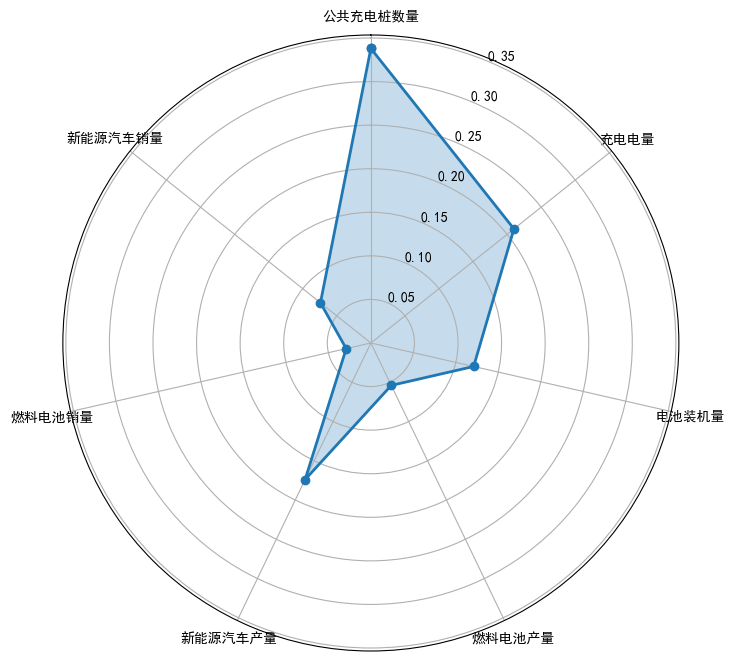

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 指标权重数据
indicators = ["公共充电桩数量", "充电电量", "电池装机量", "燃料电池产量", 
             "新能源汽车产量", "燃料电池销量", "新能源汽车销量"]
weights = np.array([0.338, 0.210, 0.121, 0.054, 0.174, 0.029, 0.074])

# 3. 雷达图绘制
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# 角度计算与闭合处理
angles = np.linspace(0, 2*np.pi, len(weights), endpoint=False).tolist()
angles += angles[:1]  # 闭合处理
weights = np.concatenate((weights, [weights[0]]))  # 数据闭合

# 绘图
ax.plot(angles, weights, 'o-', linewidth=2)
ax.fill(angles, weights, alpha=0.25)

# 标签设置
ax.set_theta_offset(np.pi/2)  # 起始角度设置为12点方向
ax.set_theta_direction(-1)     # 顺时针排列指标
plt.xticks(angles[:-1], indicators)  # 最后一个角度是重复值，需排除

plt.show()